In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from src import *
from utils import *
import scipy.sparse as sparse
import scipy.sparse.linalg as splinalg

def generate_semi_torus(N, R=2.0, r=1.0):
    theta, phi = sp.symbols('theta phi', real=True)

    x_sym = (R + r * sp.cos(theta)) * sp.cos(phi)
    y_sym = (R + r * sp.cos(theta)) * sp.sin(phi)
    z_sym = r * sp.sin(theta)

    manifold = Manifold([theta, phi], [x_sym, y_sym, z_sym])
    manifold.compute()

    theta_range = (0, 2*np.pi)
    phi_range = (0, np.pi)

    phi_min = phi_range[0]
    phi_max = phi_range[1]

    num_boundary = 2 * int(np.round(np.sqrt(2*r/R)*np.sqrt(N)))
    num_interior = N - num_boundary

    manifold.sample([theta_range, phi_range], num_interior)

    # sample boundary

    x_sym_left = (R + r * sp.cos(theta)) * sp.cos(phi_min)
    y_sym_left = (R + r * sp.cos(theta)) * sp.sin(phi_min)

    boundary_left = Manifold([theta], [x_sym_left, y_sym_left, z_sym])
    boundary_left.sample([theta_range], num_boundary // 2)

    x_sym_right = (R + r * sp.cos(theta)) * sp.cos(phi_max)
    y_sym_right = (R + r * sp.cos(theta)) * sp.sin(phi_max)

    boundary_right = Manifold([theta], [x_sym_right, y_sym_right, z_sym])
    boundary_right.sample([theta_range], num_boundary // 2)

    manifold.params = np.vstack([
        manifold.params,
        np.insert(boundary_left.params, 1, values=phi_min, axis=1),
        np.insert(boundary_right.params, 1, values=phi_max, axis=1)
    ])

    manifold.points = np.vstack([
        manifold.points,
        boundary_left.points,
        boundary_right.points
    ])

    id_interior = np.arange(num_interior)
    id_boundary = np.arange(num_interior, N)

    # outward normal at each boundary point
    n_vecs = np.zeros((num_boundary, manifold.n)) # shape: (num_boundary, n)

    for i in range(num_boundary):
        n_vecs[i, :] = [0.0, -1.0, 0.0]

    manifold.id_interior = id_interior
    manifold.id_boundary = id_boundary

    manifold.build_tree()

    return manifold, id_interior, id_boundary, n_vecs

def compute_mms_torus(manifold, n_vecs):
    theta, phi = manifold.xi
    id_interior = manifold.id_interior
    id_boundary = manifold.id_boundary

    u_sym = sp.sin(theta) * sp.cos(phi + sp.pi/4)

    # sym computation
    u_lap_sym = manifold.get_laplacian(u_sym)
    u_grad_sym = manifold.get_gradient(u_sym)
    f_sym = -u_lap_sym

    # lambdify
    u_func = sp.lambdify((theta, phi), u_sym, 'numpy')
    f_func = sp.lambdify((theta, phi), f_sym, 'numpy')
    u_lap_func = sp.lambdify((theta, phi), u_lap_sym, 'numpy')
    u_grad_func = sp.lambdify((theta, phi), u_grad_sym, 'numpy')

    # get values
    tt = manifold.params[:, 0]
    pp = manifold.params[:, 1]

    u_vals = u_func(tt, pp)
    f_I = f_func(tt, pp)[id_interior]
    u_lap_vals = u_lap_func(tt, pp)

    u_grad_vals = u_grad_func(tt, pp) # shape: (n, 1, N)
    u_grad_vals_boundary = u_grad_vals.squeeze()[:, id_boundary].T # shape: (num_boundary, n)
    # g = u + du/dn
    g_B = u_vals[id_boundary] + np.sum(n_vecs * u_grad_vals_boundary, axis=1) # shape: (num_boundary)

    return u_vals, f_I, u_lap_vals, u_grad_vals_boundary, g_B

def solve_poisson_robin_schur(L, D_n, f_I, g_B, id_interior, id_boundary, N, require_st=False):
    """
    system:
    [ A_II   A_IB ] [ u_I ] = [ f_I ]
    [ B_BI   B_BB ] [ u_B ]   [ g_B ]
    """
    L_csr = L.tocsr()
    D_n_csr = D_n.tocsr()

    num_boundary = len(id_boundary)

    A = -L_csr
    A_II = A[:, id_interior]
    A_IB = A[:, id_boundary]

    B_BI = D_n_csr[:, id_interior] 
    
    I_B = sparse.eye(num_boundary, format='csr')
    B_BB = D_n_csr[:, id_boundary] + I_B

    B_BB_diag = B_BB.diagonal()
    B_BB_inv = sparse.diags(1.0 / B_BB_diag, format='csr')

    A_prime = A_II - A_IB @ B_BB_inv @ B_BI
    b_prime = f_I - A_IB @ (B_BB_inv @ g_B)

    u_num_interior = splinalg.spsolve(A_prime, b_prime)

    u_num_boundary = B_BB_inv @ (g_B - B_BI @ u_num_interior)

    u_num = np.zeros(N)
    u_num[id_interior] = u_num_interior
    u_num[id_boundary] = u_num_boundary

    if require_st:
        return u_num, np.linalg.norm(np.linalg.inv(A_prime.toarray()), ord=np.inf)
    return u_num

In [3]:
#-- PARAMETERS --#

N=6400
seed=2

if seed is not None:
    np.random.seed(seed)

#-- GEOMETRY --#

manifold, id_interior, id_boundary, n_vecs = generate_semi_torus(N)

num_interior = len(id_interior)
num_boundary = len(id_boundary)

In [61]:
l = 5
K = 30

id_ill = []

for i, i_id in enumerate(id_interior):
    fetcher_in = lambda k: manifold.get_in_stencil(i_id, k)
    tangent_basis = manifold.get_local_basis(manifold.params[i_id])[0]

    K_current = K
    max_retries_auto_K = 15

    # auto K
    for retries in range(max_retries_auto_K + 1):
        stencil_points, stencil_ids = fetcher_in(K_current)
        
        weights = get_operator_weights(
            stencil=stencil_points,
            tangent_basis=tangent_basis,
            l=l,
        )
        
        w_center, w_neighbors = weights[0], weights[1:]
        
        is_correct_sign = (w_center * -1) > 0.0
        ratio = np.abs(w_center) / np.max(np.abs(w_neighbors))
        is_stable = ratio >= 3.0

        if is_correct_sign and is_stable:
            break

        K_current += 2
    
    if (not is_correct_sign) or (not is_stable):
        id_ill.append(i_id)

In [62]:
len(id_ill)

70

In [83]:
K = 35
all_weights = np.zeros((len(id_ill), K))
none_counts = 0
zero_counts = 0

for i, i_id in enumerate(id_ill):
    fetcher_in = lambda k: manifold.get_in_stencil(i_id, k)
    tangent_basis = manifold.get_local_basis(manifold.params[i_id])[0]

    K_current = K
    max_retries_auto_K = 15

    # auto K
    stencil_points, stencil_ids = fetcher_in(K_current)
    
    weights = get_operator_weights(
        stencil=stencil_points,
        tangent_basis=tangent_basis,
        l=l,
        operator='lap',
        opt='qp',
    )

    if weights is None:
        none_counts += 1
    else:
        if weights[0] == 0.0:
            zero_counts += 1

    all_weights[i, :] = weights

In [84]:
none_counts

0

In [85]:
w_center, w_neighbors = all_weights[:, 0], all_weights[:, 1:]
ratio = np.abs(w_center) / np.max(np.abs(w_neighbors), axis=1) 
np.argmax(w_center)

np.int64(61)

In [90]:
i_id = id_ill[61]

fetcher_in = lambda k: manifold.get_in_stencil(i_id, k)
tangent_basis = manifold.get_local_basis(manifold.params[i_id])[0]

K_current = 45
max_retries_auto_K = 15

# auto K
stencil_points, stencil_ids = fetcher_in(K_current)

weights = get_operator_weights(
    stencil=stencil_points,
    tangent_basis=tangent_basis,
    l=l,
    operator='lap',
    opt='qp',
)

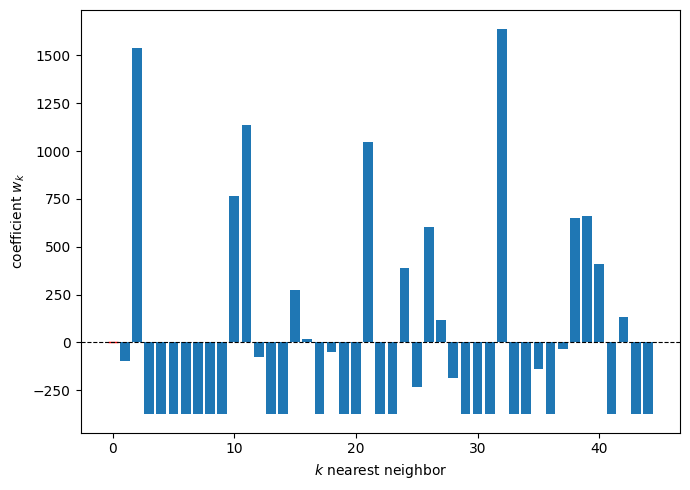

In [91]:
plot_weights(weights)

In [13]:
l_dn = 5
K_dn = 35

b_id_ill = []
records = np.zeros((num_boundary, 2))

for i, b_id in enumerate(id_boundary):
    n_vec = n_vecs[i]
    enhanced_tree = manifold.build_enhanced_tree(b_id, enhance_direction=-n_vec)
    fetcher_bd = lambda k: manifold.get_bd_stencil(b_id, k, method='restricted', enhanced_tree=enhanced_tree)

    tangent_basis = manifold.get_local_basis(manifold.params[b_id])[0]

    K_current = K_dn
    max_retries_auto_K = 15

    # auto K
    for retries in range(max_retries_auto_K + 1):

        stencil_points, stencil_ids = fetcher_bd(K_current)
        
        weights = get_operator_weights(
            stencil=stencil_points,
            tangent_basis=tangent_basis,
            l=l_dn,
            operator='dn',
            n_vec=n_vec,
        )
        
        w_center, w_neighbors = weights[0], weights[1:]
        
        is_correct_sign = (w_center * 1) > 0.0
        ratio = np.abs(w_center) / np.max(np.abs(w_neighbors))
        is_stable = ratio >= 3.0

        if is_correct_sign and is_stable:
            break

        K_current += 2
    
    w_center, w_neighbors = weights[0], weights[1:]
        
    is_correct_sign = (w_center * 1) > 0.0
    ratio = np.abs(w_center) / np.max(np.abs(w_neighbors))

    records[i, 0] = is_correct_sign
    records[i, 1] = ratio
    if (not is_correct_sign) or (not is_stable):
        b_id_ill.append(b_id)

In [14]:
len(b_id_ill)

138

In [43]:
K_dn += 5
all_bd_weights = np.zeros((len(b_id_ill), K_dn))
none_counts = 0

for i, b_id in enumerate(b_id_ill):
    n_vec = n_vecs[i]
    enhanced_tree = manifold.build_enhanced_tree(b_id, enhance_direction=-n_vec)
    fetcher_bd = lambda k: manifold.get_bd_stencil(b_id, k, method='restricted', enhanced_tree=enhanced_tree)

    tangent_basis = manifold.get_local_basis(manifold.params[b_id])[0]

    K_current = K_dn

    # auto K
    stencil_points, stencil_ids = fetcher_bd(K_current)
    
    weights = get_operator_weights(
        stencil=stencil_points,
        tangent_basis=tangent_basis,
        l=l_dn,
        operator='dn',
        n_vec=n_vec,
        opt='qp'
    )
    if weights is None:
        none_counts += 1

    all_bd_weights[i, :] = weights

In [44]:
none_counts

0

In [46]:
w_center, w_neighbors = all_bd_weights[:, 0], all_bd_weights[:, 1:]
ratio = np.abs(w_center) / np.max(np.abs(w_neighbors), axis=1) 
np.min(ratio)

np.float64(0.2379938021057807)

In [34]:
b_id_ill[76]

np.int64(6335)

In [41]:
b_id = 6335

n_vec = n_vecs[0]
enhanced_tree = manifold.build_enhanced_tree(b_id, enhance_direction=-n_vec)
fetcher_bd = lambda k: manifold.get_bd_stencil(b_id, k, method='restricted', enhanced_tree=enhanced_tree)

tangent_basis = manifold.get_local_basis(manifold.params[b_id])[0]

K_current = K_dn + 15

# auto K
stencil_points, stencil_ids = fetcher_bd(K_current)

weights = get_operator_weights(
    stencil=stencil_points,
    tangent_basis=tangent_basis,
    l=l_dn,
    operator='dn',
    n_vec=n_vec,
    opt='qp'
)

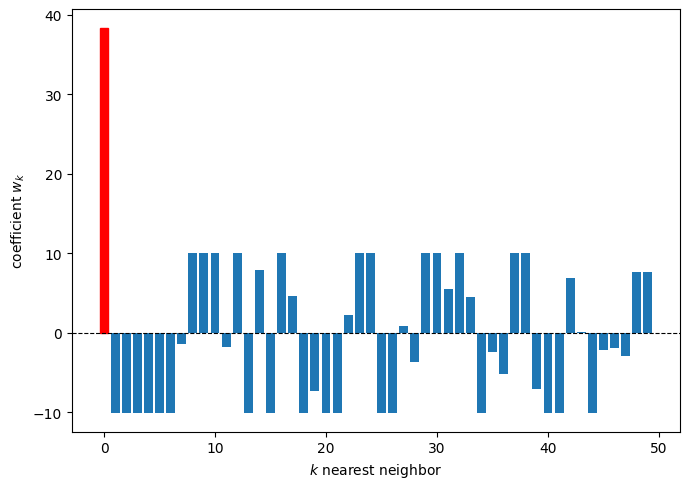

In [42]:
plot_weights(weights)